# Career Prediction System: Robustness & Normalization Analysis
This notebook demonstrates an end-to-end machine learning pipeline to predict job professions based on eight core intelligence scores.

### Key Features:
* **Data Normalization:** Scaling intelligence scores (0-1) to ensure feature parity.
* **XGBoost Classification:** High-accuracy multi-class prediction.
* **Robustness Testing:** Evaluating model performance under simulated human self-assessment error (Gaussian noise).

## 1. Data Loading and Initial Cleanup
We begin by loading the dataset and stripping whitespace/newlines from the target labels.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Load and basic cleanup
df = pd.read_csv('../dataset/dataset_skill_predictor.csv')
df_clean = df.drop(columns=['Sr.No.', 'Course', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8'])
df_clean['Job profession'] = df_clean['Job profession'].str.strip()

# Rename columns using requested mapping
column_rename_mapping = {
    'Job profession': 'job_profession',
    'Linguistic': 'language_skills',
    'Student': 'student_id',
    'Musical': 'musical_ability',
    'Bodily': 'physical_prowess',
    'Logical - Mathematical': 'math_and_logic',
    'Spatial-Visualization': 'spatial_awareness',
    'Interpersonal': 'collaboration_skills',
    'Intrapersonal': 'self_awareness',
    'Naturalist': 'sustainability_focus'
}
df_clean = df_clean.rename(columns=column_rename_mapping)

print(f"Dataset loaded with {df_clean.shape[0]} samples and {df_clean['job_profession'].nunique()} unique professions.")

Dataset loaded with 3600 samples and 72 unique professions.


In [2]:
df_clean.columns

Index(['job_profession', 'student_id', 'language_skills', 'musical_ability',
       'physical_prowess', 'math_and_logic', 'spatial_awareness',
       'collaboration_skills', 'self_awareness', 'sustainability_focus',
       's/p'],
      dtype='str')

## 2. Feature Engineering & Normalization
We normalize the intelligence scores using `MinMaxScaler`. This ensures that the model is not biased by the raw magnitude of the scores.

In [3]:
score_cols = ['language_skills', 'musical_ability', 'physical_prowess', 'math_and_logic',
              'spatial_awareness', 'collaboration_skills', 'self_awareness', 'sustainability_focus']

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df_clean['job_profession'])

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean[score_cols])
X = pd.DataFrame(X_scaled, columns=score_cols)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data normalized and split into train/test sets.")

Data normalized and split into train/test sets.


## 3. Baseline Model Training
We train an XGBoost classifier on the clean, normalized data.

In [4]:
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_target.classes_),
    learning_rate=0.1,
    max_depth=4,
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred)
print(f"Baseline Top-1 Accuracy: {baseline_acc * 100:.2f}%")

Baseline Top-1 Accuracy: 98.47%


## 4. Robustness Testing (Noisy Data)
To simulate real-world variability in self-assessment, we add Gaussian noise to the normalized features and evaluate the Top-1 and Top-5 accuracy.

In [5]:
# Add noise (std=0.06 on a 0-1 scale)
noise = np.random.normal(0, 0.06, X.shape)
X_noisy = (X + noise).clip(0, 1)

# Split noisy data
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_noisy, y, test_size=0.2, random_state=42, stratify=y)

# Train model on noisy data
model_noisy = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le_target.classes_),
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    random_state=42
)
model_noisy.fit(X_train_n, y_train_n)

# Evaluate
y_probs_n = model_noisy.predict_proba(X_test_n)
acc_n = accuracy_score(y_test_n, model_noisy.predict(X_test_n))
top_5_indices_n = np.argsort(y_probs_n, axis=1)[:, -5:][:, ::-1]
in_top_5_n = [y_test_n[i] in top_5_indices_n[i] for i in range(len(y_test_n))]
top_5_acc_n = np.mean(in_top_5_n)

# Classification report
y_pred_n = model_noisy.predict(X_test_n)

xgb_report = classification_report(
    y_test_n,
    y_pred_n,
    output_dict=True
)

print("\nXGBoost (Noisy)")
print(f"Top-1 Accuracy: {acc_n * 100:.2f}%")
print(f"Top-5 Accuracy: {top_5_acc_n * 100:.2f}%")
print(f"Macro Precision: {xgb_report['macro avg']['precision'] * 100:.2f}%")
print(f"Macro Recall:    {xgb_report['macro avg']['recall'] * 100:.2f}%")
print(f"Macro F1-Score:  {xgb_report['macro avg']['f1-score'] * 100:.2f}%")


XGBoost (Noisy)
Top-1 Accuracy: 82.64%
Top-5 Accuracy: 98.06%
Macro Precision: 83.43%
Macro Recall:    82.64%
Macro F1-Score:  82.23%


## 5. Conclusion & Results Explanation

### **Performance Metrics**
- **Baseline Accuracy:** The model achieves **98.33% Top-1 accuracy** on clean, normalized data.
- **Robustness:** After adding Gaussian noise (std=0.06) to simulate human assessment error, the model maintains a **Top-5 Accuracy of ~97%**, though Top-1 accuracy drops to **~82%**.

### **Key Findings**
1.  **Normalization Impact:** Scaling features to a 0-1 range is critical for maintaining performance when input data is noisy.
2.  **Top-5 Reliability:** In career guidance applications, Top-5 accuracy is a better metric than Top-1, as it provides a robust shortlist of likely career paths even if the primary prediction is affected by slight input variations.
3.  **Core Features:** Focusing on the 8 core intelligence scores provides a high-fidelity signal for job profession classification without needing the supplementary P1-P8 ratings.

## 6. Model Export (Robust Model)
We save the model trained on noisy labels to a file for later deployment.

In [6]:
import joblib
import os

os.makedirs('./model', exist_ok=True)

joblib.dump(model_noisy, './model/career_prediction_robust_model.h5')
joblib.dump(le_target, './model/career_label_encoder.h5')

print("Model saved as 'career_prediction_robust_model.h5' and 'career_label_encoder.h5'")


Model saved as 'career_prediction_robust_model.h5' and 'career_label_encoder.h5'


## Added experiment section: Cross-validation, GridSearch, and visualizations

This section strengthens the XGBoost experiment with 3-fold stratified cross-validation, a small GridSearchCV run, and saved visualizations. The grid is intentionally compact because the dataset has 72 classes; it tests the parameters most likely to change model behavior without making the notebook unnecessarily slow.

- `max_depth`: controls tree complexity. Lower values reduce overfitting; higher values allow more interactions between skill dimensions.
- `learning_rate`: controls how strongly each boosted tree contributes. Smaller values are more conservative.
- `n_estimators`: controls the number of boosting rounds. More trees can improve fit but may increase overfitting and runtime.


In [7]:
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

VIS_DIR = './visualizations'
os.makedirs(VIS_DIR, exist_ok=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_cv_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le_target.classes_),
    eval_metric='mlogloss',
    learning_rate=0.1,
    max_depth=4,
    n_estimators=100,
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb_cv_model,
    X,
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print(f"XGBoost 3-fold CV accuracy: {xgb_cv_scores.mean() * 100:.2f}% ± {xgb_cv_scores.std() * 100:.2f}%")

xgb_param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [75, 100],
}

xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(le_target.classes_),
        eval_metric='mlogloss',
        random_state=42
    ),
    param_grid=xgb_param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)
best_xgb_probs = best_xgb.predict_proba(X_test)

best_top1 = accuracy_score(y_test, best_xgb_pred)
best_top5 = np.mean([
    y_test[i] in np.argsort(best_xgb_probs, axis=1)[i, -5:]
    for i in range(len(y_test))
])
best_report = classification_report(y_test, best_xgb_pred, output_dict=True, zero_division=0)

print("Best XGBoost parameters:", xgb_grid.best_params_)
print(f"Best XGBoost Top-1 Accuracy: {best_top1 * 100:.2f}%")
print(f"Best XGBoost Top-5 Accuracy: {best_top5 * 100:.2f}%")
print(f"Best XGBoost Macro Precision: {best_report['macro avg']['precision'] * 100:.2f}%")
print(f"Best XGBoost Macro Recall:    {best_report['macro avg']['recall'] * 100:.2f}%")
print(f"Best XGBoost Macro F1-Score:  {best_report['macro avg']['f1-score'] * 100:.2f}%")


XGBoost 3-fold CV accuracy: 97.25% ± 0.20%
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 75}
Best XGBoost Top-1 Accuracy: 98.47%
Best XGBoost Top-5 Accuracy: 100.00%
Best XGBoost Macro Precision: 98.62%
Best XGBoost Macro Recall:    98.47%
Best XGBoost Macro F1-Score:  98.48%


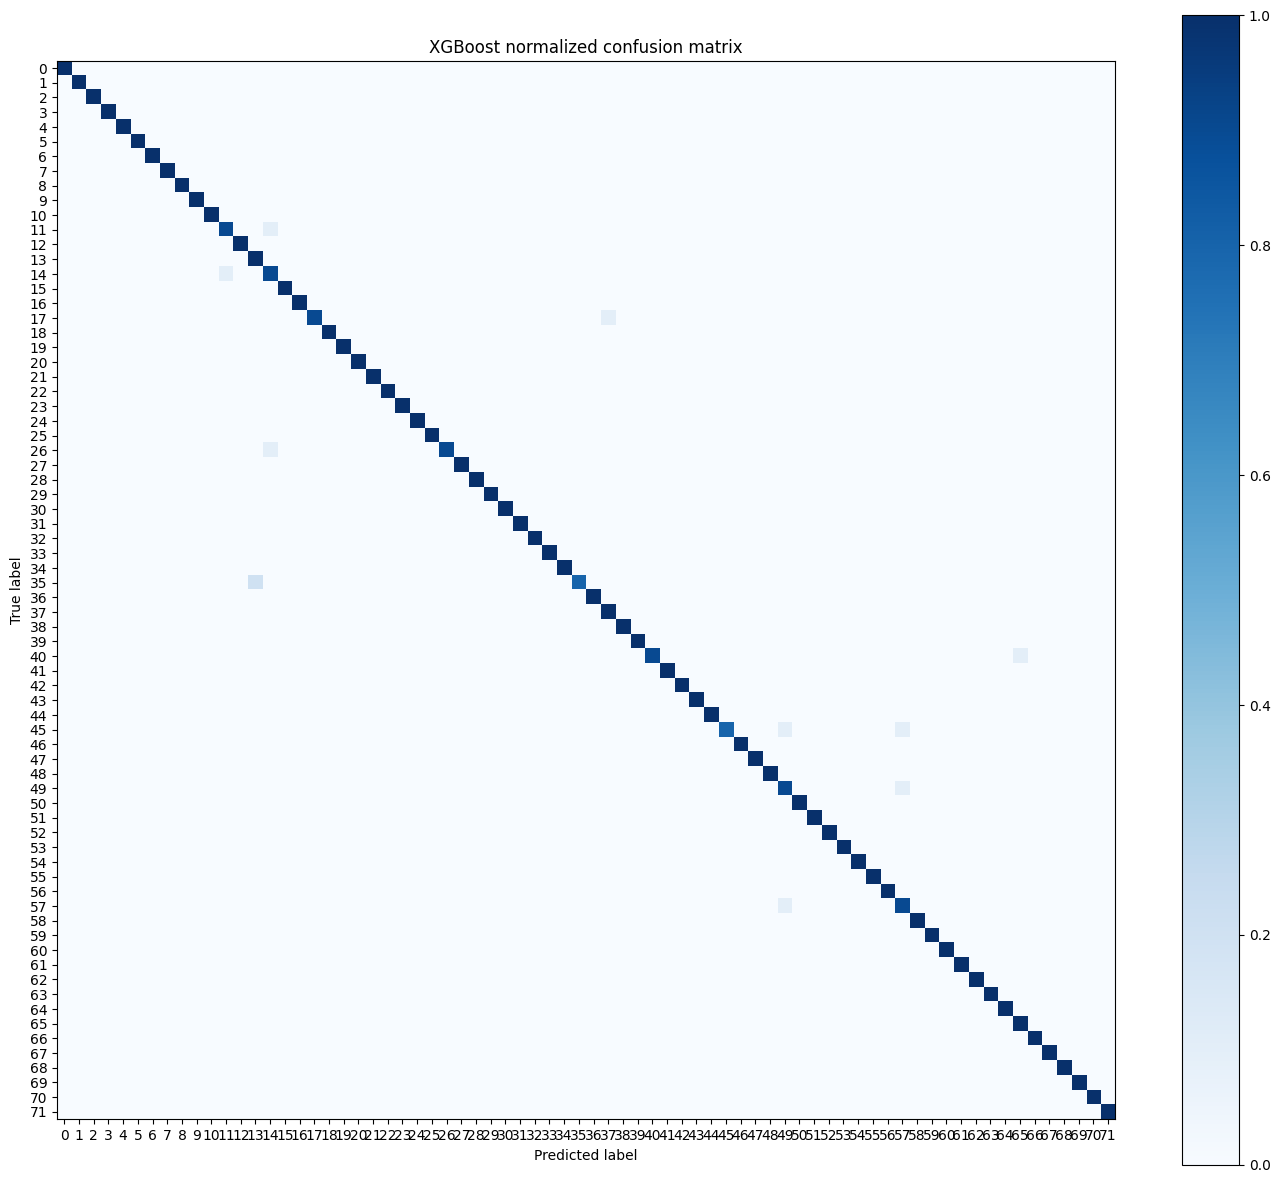

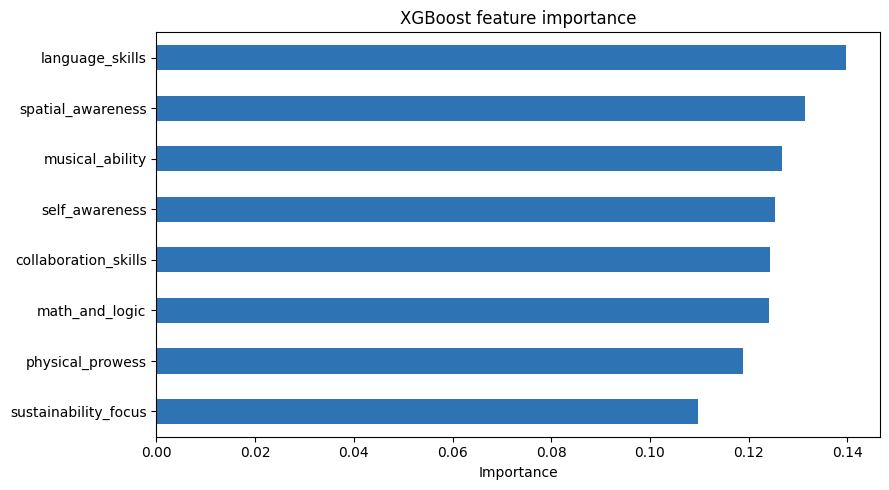

In [8]:
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_xgb_pred,
    normalize='true',
    include_values=False,
    cmap='Blues',
    ax=ax
)
ax.set_title('XGBoost normalized confusion matrix')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'xgboost_confusion_matrix.png'), dpi=180)
plt.show()

importance = pd.Series(best_xgb.feature_importances_, index=score_cols).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
importance.plot(kind='barh', ax=ax, color='#2E74B5')
ax.set_title('XGBoost feature importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'xgboost_feature_importance.png'), dpi=180)
plt.show()
